# Step 4 Multivariate Analysis

In [86]:
import pandas as pd 
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure

In [87]:
dataset = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/Final_Dataset.csv')

In [88]:
dataset

,Brand,Price_USD,Rating,Number_of_Reviews,Is_Certified_Cruelty_Free,Toxic_Chemical_Amount,Is_Skincare,Skin_Type,Product_Size,Usage_Frequency,Gender_Target,Packaging_Type,Has_Active_Ingredients,European_Origin
0,Anastasia Beverly Hills,81.651274,3.052846,5023.463415,1,369,0.287263,2.016260,127.940379,1.764228,0.357724,1.878049,0.571816,0.482385
1,Becca,82.545799,3.100000,5134.048969,0,388,0.329897,1.981959,128.479381,1.716495,0.311856,1.827320,0.572165,0.494845
2,Bite Beauty,77.430128,3.065816,5229.767857,1,392,0.331633,2.043367,121.096939,1.790816,0.354592,1.882653,0.576531,0.482143
3,Bobby Brown,77.818684,2.966579,5035.418421,0,380,0.302632,2.057895,137.000000,1.765789,0.355263,1.826316,0.576316,0.489474
4,Bourjois,80.552185,2.943417,5014.554622,0,357,0.274510,1.960784,123.389356,1.829132,0.327731,1.823529,0.585434,0.549020
5,Charlotte Tilbury,79.836731,3.000275,4982.079670,0,364,0.260989,2.030220,131.483516,1.758242,0.302198,1.876374,0.571429,0.500000
6,Clinique,80.527825,2.914854,5267.143236,0,377,0.339523,2.079576,131.299735,1.652520,0.323607,1.830239,0.562334,0.501326
7,ColourPop,80.275549,3.039024,5263.231707,0,328,0.295732,2.015244,132.957317,1.695122,0.347561,1.899390,0.524390,0.512195
8,Danessa Myricks,81.357933,2.958939,5165.142458,0,358,0.284916,2.005587,134.636872,1.709497,0.335196,1.865922,0.594972,0.553073
9,Drunk Elephant,76.979891,2.959511,4999.342391,1,368,0.282609,2.065217,130.489130,1.668478,0.323370,1.842391,0.562500,0.505435


In [89]:
print(dataset.columns.tolist())

['Brand', 'Price_USD', 'Rating', 'Number_of_Reviews', 'Is_Certified_Cruelty_Free', 'Toxic_Chemical_Amount', 'Is_Skincare', 'Skin_Type', 'Product_Size', 'Usage_Frequency', 'Gender_Target', 'Packaging_Type', 'Has_Active_Ingredients', 'European_Origin']


# Multiple Linear Regression

Checking the Relationships between Variables using Correlation and Scatter Plots

In [90]:
# Define all the variables
brand = dataset['Brand']
price = dataset['Price_USD']
rating = dataset['Rating']
reviews = dataset['Number_of_Reviews']
is_cruelty_free = dataset['Is_Certified_Cruelty_Free']
toxic_chemicals = dataset['Toxic_Chemical_Amount']
skincare = dataset['Is_Skincare']
skin_type = dataset['Skin_Type']
product_size = dataset['Product_Size']
usage = dataset['Usage_Frequency']
gender = dataset['Gender_Target']
packaging = dataset['Packaging_Type']
active_ingredients = dataset['Has_Active_Ingredients']
EU_origin = dataset['European_Origin']


Diagram 1: Heatmap of Correlations


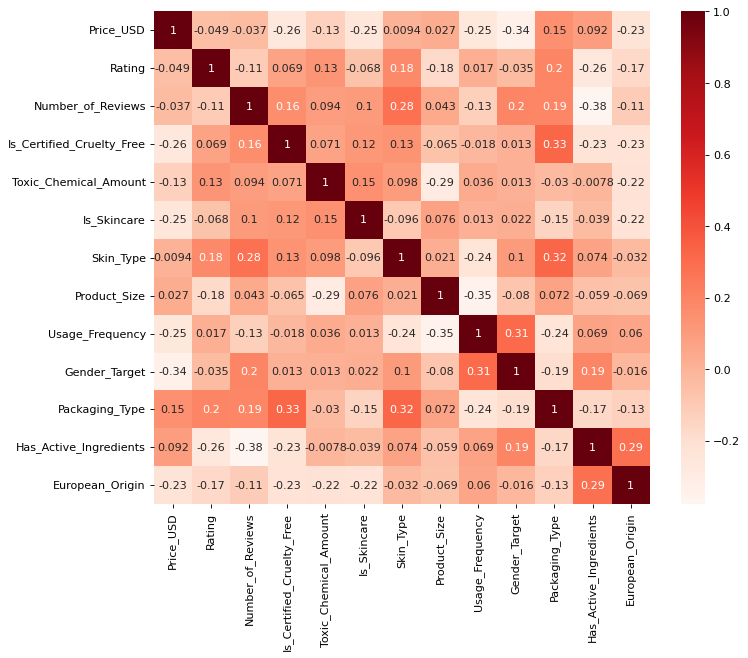

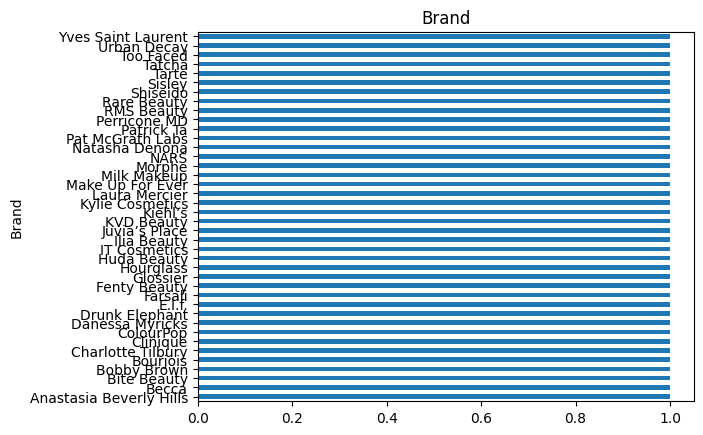

In [91]:
# Heatmap 
figure(num=None, figsize=(10, 8), dpi=80, facecolor='w', edgecolor='k')
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap = 'Reds')
print("Diagram 1: Heatmap of Correlations")
plt.show()

numberRating = dataset.Brand.value_counts() 
numberRating.plot.barh()
plt.title("Brand")
plt.show()

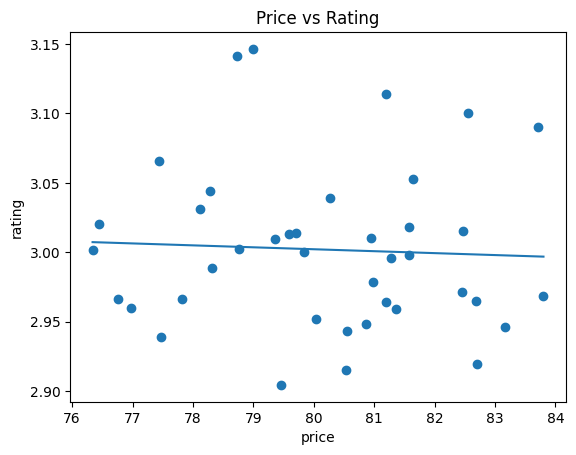

In [92]:
plt.title("Price vs Rating")
plt.xlabel("price")
plt.ylabel("rating")
plt.scatter(price, rating)
plt.plot(np.unique(price), np.poly1d(np.polyfit(price, rating, 1))(np.unique(price)))
plt.show()

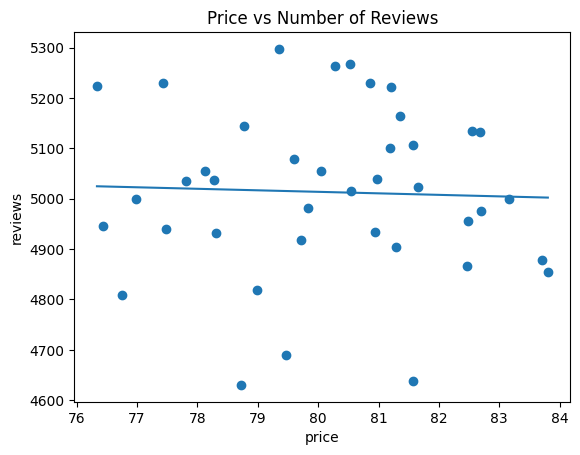

In [93]:
plt.title("Price vs Number of Reviews")
plt.xlabel("price")
plt.ylabel("reviews")
plt.scatter(price, reviews)
plt.plot(np.unique(price), np.poly1d(np.polyfit(price, reviews, 1))(np.unique(price)))
plt.show()

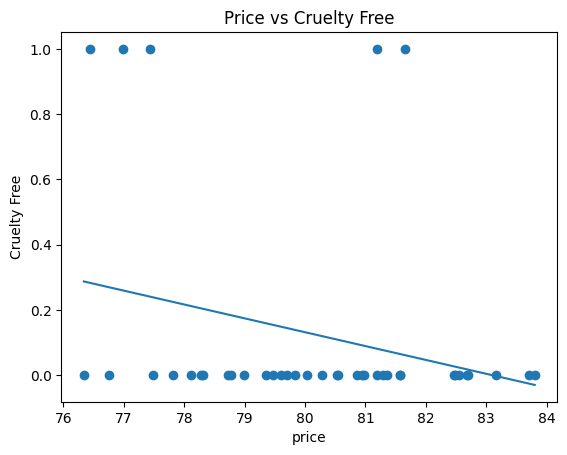

In [94]:
plt.title("Price vs Cruelty Free")
plt.xlabel("price")
plt.ylabel("Cruelty Free")
plt.scatter(price, is_cruelty_free)
plt.plot(np.unique(price), np.poly1d(np.polyfit(price, is_cruelty_free, 1))(np.unique(price)))
plt.show()

# Principal Component Analysis


In [95]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA

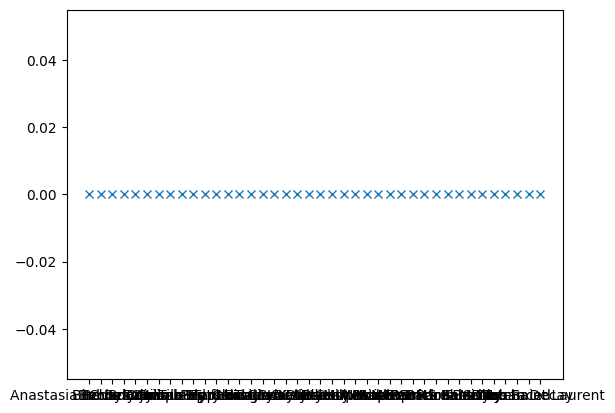

In [96]:
plt.plot(brand, np.zeros_like(brand), 'x')

In [97]:
X = dataset.drop(columns=['Brand'])
y = dataset.columns

In [98]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 7.38050226e-01,  8.80826437e-01,  6.16900791e-02,
         2.64575131e+00, -2.83015719e-01, -5.61483713e-01,
         4.65149831e-01, -3.22690572e-01,  4.80697051e-01,
         9.71680365e-01,  1.08800059e+00, -2.65245879e-02,
        -6.59994144e-01],
       [ 1.17759466e+00,  1.69631405e+00,  7.37002371e-01,
        -3.77964473e-01,  6.13200725e-01,  1.29705095e+00,
        -4.44747381e-01, -1.95113725e-01, -4.44557607e-01,
        -7.64076641e-01, -4.98248085e-01, -1.25304154e-02,
        -1.72256294e-01],
       [-1.33610173e+00,  1.10514292e+00,  1.32152846e+00,
         2.64575131e+00,  8.01877872e-01,  1.37271688e+00,
         1.18420945e+00, -1.94247030e+00,  9.96093288e-01,
         8.53167425e-01,  1.23197162e+00,  1.62408164e-01,
        -6.69465350e-01],
       [-1.14517597e+00, -6.11064483e-01,  1.34695661e-01,
        -3.77964473e-01,  2.35846433e-01,  1.08480406e-01,
         1.56957074e+00,  1.82163866e+00,  5.10971660e-01,
         8.78571907e-01, -5.29635801e

In [99]:
from sklearn.decomposition import PCA
pca = PCA(0.95) 
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(40, 11)

Need 11 principal components 

In [100]:
X_pca

array([[ 1.64838479e+00, -8.95286089e-01, -8.49331404e-01,
         7.75400401e-01, -7.93618352e-01, -1.20327944e-01,
         6.78620229e-01,  2.04551243e+00, -2.01594749e-01,
        -6.36381251e-01, -2.24885486e-01],
       [ 6.71330515e-01,  6.89751341e-02, -6.20077102e-01,
        -1.34922249e+00,  9.20983166e-01,  1.12002185e-01,
         1.63552194e-01, -1.08914202e+00,  1.12722417e+00,
        -2.53149729e-01, -5.84807024e-01],
       [ 1.98976299e+00, -3.67578633e+00, -6.72648392e-01,
         9.94424298e-01, -1.80590947e-02, -9.35205726e-01,
        -3.79005005e-01,  1.17454942e+00,  1.19062720e+00,
        -3.06704763e-01, -2.27452139e-01],
       [-8.52341078e-02, -5.74588572e-01,  1.56618823e+00,
         1.05543372e+00,  5.89601179e-01, -2.04379017e-01,
         1.19955679e+00, -4.81979175e-01, -7.36158061e-01,
         6.39038788e-01,  1.47967852e+00],
       [-2.58962917e+00,  1.34701084e-01, -6.98304149e-01,
         6.83549079e-01, -1.23504837e+00,  1.03961053e+00,
  

In [101]:
per_var = pca.explained_variance_ratio_
per_var

array([0.17054768, 0.14727831, 0.11021545, 0.10584056, 0.08768528,
       0.07733068, 0.06966904, 0.06801946, 0.04818961, 0.04036247,
       0.03495469])

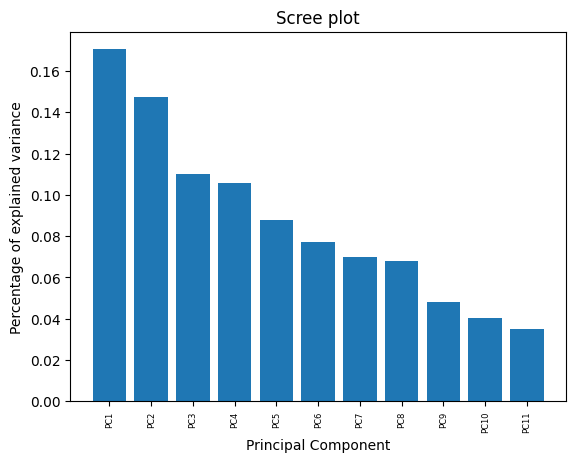

In [102]:
labels = ['PC' + str(i) for i in range(1, len(per_var)+1)]
plt.bar(x = range(1, len(per_var)+1), height = per_var, tick_label=labels)
plt.xticks(rotation='vertical', fontsize=6)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principal Component")
plt.title("Scree plot")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1,) and (11,)

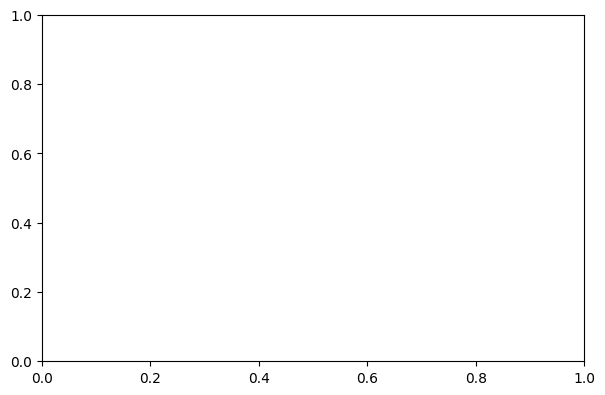

In [103]:
import matplotlib.pyplot as plt
import numpy as np 

pc_values = np.arange(pca.n_components) + 1 
plt.figure(figsize=(7, 4.5))
plt.plot(pc_values, pca.explained_variance_ratio_, 'o-', linewidth=1.5, markersize=5, color='#4A2E80')
plt.title('Scree Plot: Variance Explained by each Principal Component')
plt.xlabel('Principal Component', fontsize=9)
plt.ylabel('Variance Explained', fontsize=9)
plt.xticks(pc_values, fontsize=8)
plt.yticks(fontsize=8)
plt.show()

In [ ]:
pca.n_components_

np.int64(11)

In [ ]:
pca.explained_variance_

array([2.27396913, 1.9637108 , 1.46953932, 1.41120749, 1.169137  ,
       1.03107572, 0.92892054, 0.90692616, 0.64252812, 0.53816633,
       0.46606247])

Kaiser Criterion to select the amount of PC'S

In [ ]:
pca = PCA(n_components=11)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(40, 11)

In [ ]:
pca.explained_variance_ratio_

array([0.17054768, 0.14727831, 0.11021545, 0.10584056, 0.08768528,
       0.07733068, 0.06966904, 0.06801946, 0.04818961, 0.04036247,
       0.03495469])

In [ ]:
pca.explained_variance_

array([2.27396913, 1.9637108 , 1.46953932, 1.41120749, 1.169137  ,
       1.03107572, 0.92892054, 0.90692616, 0.64252812, 0.53816633,
       0.46606247])

In [ ]:
loading_scores = pd.Series(pca.components_[0], index = X.columns)
print(*loading_scores)
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)

0.0976598754559779 0.22565787499463474 0.33707267101252253 0.33477109134438193 0.10022909718951002 0.03580980366470786 0.3110195498750643 0.11387561305879412 -0.3183743206840398 -0.16455741343755698 0.45285372137940144 -0.3827691061900027 -0.3358457107222322


In [ ]:
pc_values = sorted_loading_scores[0:13].index.values
pc_values 

array(['Packaging_Type', 'Has_Active_Ingredients', 'Number_of_Reviews',
       'European_Origin', 'Is_Certified_Cruelty_Free', 'Usage_Frequency',
       'Skin_Type', 'Rating', 'Gender_Target', 'Product_Size',
       'Toxic_Chemical_Amount', 'Price_USD', 'Is_Skincare'], dtype=object)

# Clustering 

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

In [ ]:
km = KMeans(n_clusters=3, n_init='auto', random_state=0)
y_predicted = km.fit_predict(dataset[['Price_USD', 'Rating']])
dataset['cluster'] = y_predicted

In [ ]:
df0 = dataset[dataset.cluster == 0]
df1 = dataset[dataset.cluster == 1]
df2 = dataset[dataset.cluster == 2]

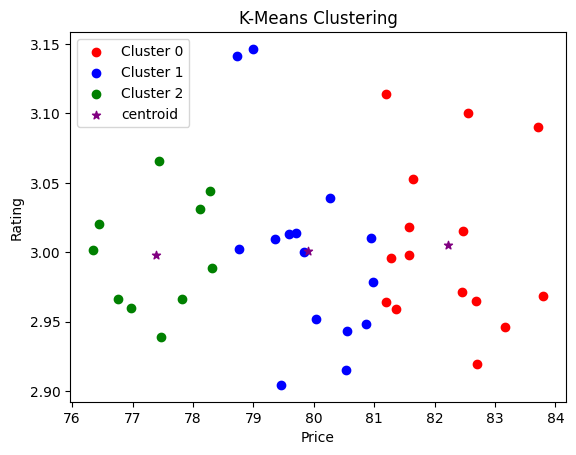

In [ ]:
plt.scatter(df0.Price_USD, df0.Rating, color='red', label='Cluster 0')
plt.scatter(df1.Price_USD, df1.Rating, color='blue', label='Cluster 1')
plt.scatter(df2.Price_USD, df2.Rating, color='green', label='Cluster 2')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='purple', marker = '*', label='centroid')

plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('K-Means Clustering')
plt.legend()
plt.show()

In [ ]:
scaler = MinMaxScaler()
scaler.fit(dataset[['Price_USD']])
dataset.Price_USD = scaler.transform(dataset['Price_USD'].values.reshape(-1, 1))

c:\Users\caitl\anaconda3\envs\python_intro\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
dataset

,Brand,Price_USD,Rating,Number_of_Reviews,Is_Certified_Cruelty_Free,Toxic_Chemical_Amount,Is_Skincare,Skin_Type,Product_Size,Usage_Frequency,Gender_Target,Packaging_Type,Has_Active_Ingredients,European_Origin,cluster
0,Anastasia Beverly Hills,0.711684,3.052846,5023.463415,1,369,0.287263,2.016260,127.940379,1.764228,0.357724,1.878049,0.571816,0.482385,0
1,Becca,0.831492,3.100000,5134.048969,0,388,0.329897,1.981959,128.479381,1.716495,0.311856,1.827320,0.572165,0.494845,0
2,Bite Beauty,0.146324,3.065816,5229.767857,1,392,0.331633,2.043367,121.096939,1.790816,0.354592,1.882653,0.576531,0.482143,2
3,Bobby Brown,0.198366,2.966579,5035.418421,0,380,0.302632,2.057895,137.000000,1.765789,0.355263,1.826316,0.576316,0.489474,2
4,Bourjois,0.564477,2.943417,5014.554622,0,357,0.274510,1.960784,123.389356,1.829132,0.327731,1.823529,0.585434,0.549020,1
5,Charlotte Tilbury,0.468653,3.000275,4982.079670,0,364,0.260989,2.030220,131.483516,1.758242,0.302198,1.876374,0.571429,0.500000,1
6,Clinique,0.561214,2.914854,5267.143236,0,377,0.339523,2.079576,131.299735,1.652520,0.323607,1.830239,0.562334,0.501326,1
7,ColourPop,0.527426,3.039024,5263.231707,0,328,0.295732,2.015244,132.957317,1.695122,0.347561,1.899390,0.524390,0.512195,1
8,Danessa Myricks,0.672395,2.958939,5165.142458,0,358,0.284916,2.005587,134.636872,1.709497,0.335196,1.865922,0.594972,0.553073,0
9,Drunk Elephant,0.086022,2.959511,4999.342391,1,368,0.282609,2.065217,130.489130,1.668478,0.323370,1.842391,0.562500,0.505435,2


In [ ]:
preview_columns = dataset[['Brand', 'cluster']].head(5)

cluster_preview = preview_columns.style\
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px 12px',
        'border-bottom': '1px solid #E6E1F0', 
        'font-family': 'sans-serif',
        'font-size': '12px',
        'color': '#2D2738' 
    })\
   .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#4A2E80'), 
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '12px'),
            ('border', 'none')
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#F8F6FC') 
        ]},
        {'selector': 'tbody', 'props': [
            ('border-bottom', '2px solid #4A2E80')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('color', '#4A2E80'),
            ('padding-bottom', '8px'),
            ('text-align', 'left')
        ]}
    ])\
    .set_caption("Table: Cluster Analysis Results Preview")\
    .hide(axis='index')

cluster_preview
   

with open("cluster_preview.html", "w") as f:
    f.write(cluster_preview.to_html())

In [ ]:
scaler.fit(dataset[['Rating']])
dataset.Rating = scaler.transform(dataset['Rating'].values.reshape(-1, 1))

c:\Users\caitl\anaconda3\envs\python_intro\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
dataset

,Brand,Price_USD,Rating,Number_of_Reviews,Is_Certified_Cruelty_Free,Toxic_Chemical_Amount,Is_Skincare,Skin_Type,Product_Size,Usage_Frequency,Gender_Target,Packaging_Type,Has_Active_Ingredients,European_Origin,cluster
0,Anastasia Beverly Hills,0.711684,0.613295,5023.463415,1,369,0.287263,2.016260,127.940379,1.764228,0.357724,1.878049,0.571816,0.482385,0
1,Becca,0.831492,0.808042,5134.048969,0,388,0.329897,1.981959,128.479381,1.716495,0.311856,1.827320,0.572165,0.494845,0
2,Bite Beauty,0.146324,0.666864,5229.767857,1,392,0.331633,2.043367,121.096939,1.790816,0.354592,1.882653,0.576531,0.482143,2
3,Bobby Brown,0.198366,0.257014,5035.418421,0,380,0.302632,2.057895,137.000000,1.765789,0.355263,1.826316,0.576316,0.489474,2
4,Bourjois,0.564477,0.161357,5014.554622,0,357,0.274510,1.960784,123.389356,1.829132,0.327731,1.823529,0.585434,0.549020,1
5,Charlotte Tilbury,0.468653,0.396178,4982.079670,0,364,0.260989,2.030220,131.483516,1.758242,0.302198,1.876374,0.571429,0.500000,1
6,Clinique,0.561214,0.043391,5267.143236,0,377,0.339523,2.079576,131.299735,1.652520,0.323607,1.830239,0.562334,0.501326,1
7,ColourPop,0.527426,0.556214,5263.231707,0,328,0.295732,2.015244,132.957317,1.695122,0.347561,1.899390,0.524390,0.512195,1
8,Danessa Myricks,0.672395,0.225459,5165.142458,0,358,0.284916,2.005587,134.636872,1.709497,0.335196,1.865922,0.594972,0.553073,0
9,Drunk Elephant,0.086022,0.227823,4999.342391,1,368,0.282609,2.065217,130.489130,1.668478,0.323370,1.842391,0.562500,0.505435,2


In [ ]:
km = KMeans(n_clusters=3, n_init='auto')
y_predicted = km.fit_predict(dataset[['Price_USD', 'Rating']])
dataset['cluster'] = y_predicted

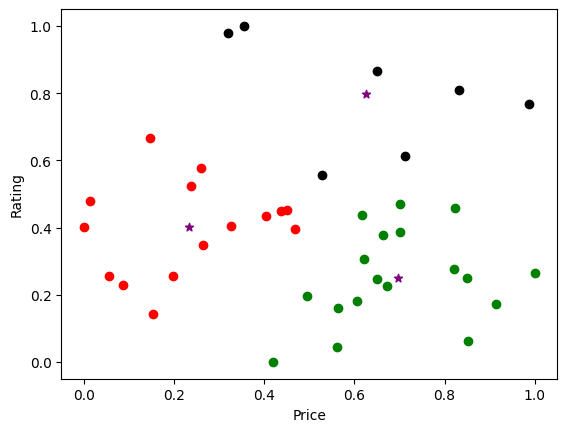

In [ ]:
df1 = dataset[dataset.cluster == 0]
df2 = dataset[dataset.cluster == 1]
df3 = dataset[dataset.cluster == 2]

plt.scatter(df1.Price_USD, df1.Rating, color='green')
plt.scatter(df2.Price_USD, df2.Rating, color='red')
plt.scatter(df3.Price_USD, df3.Rating, color='black')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='purple', marker = '*', label='centroid')
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

In [ ]:
km.cluster_centers_

array([[0.69629967, 0.25083432],
       [0.2335842 , 0.40084694],
       [0.62618023, 0.79857331]])

In [ ]:
k_range = range(1, 10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto')
    km.fit(dataset[['Price_USD', 'Rating']])
    sse.append(km.inertia_)

In [ ]:
sse

[5.25309122940622,
 3.069140164056365,
 2.0570536923391862,
 1.62981419824371,
 1.2159543121567205,
 1.0179024204267573,
 0.6522576693842717,
 0.5045063487390268,
 0.43989683297998644]

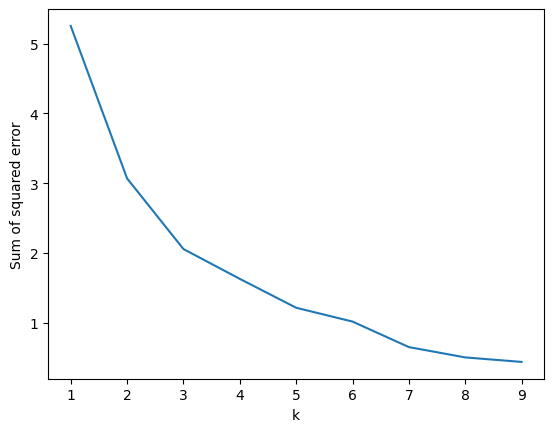

In [ ]:
plt.xlabel('k')
plt.ylabel('Sum of squared error')
plt.plot(k_range, sse)

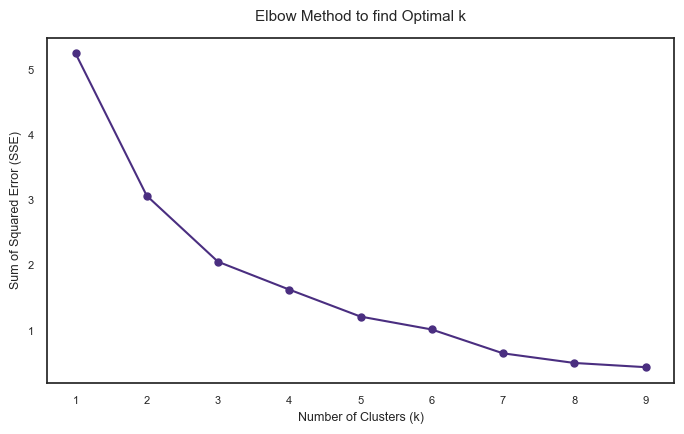

In [ ]:
plt.figure(figsize=(7, 4.5))

plt.plot(k_range, sse, 'o-', linewidth=1.5, markersize=5, color='#4A2E80')

plt.title('Elbow Method to find Optimal k', fontsize=11, pad=12)
plt.xlabel('Number of Clusters (k)', fontsize=9)
plt.ylabel('Sum of Squared Error (SSE)', fontsize=9)

plt.xticks(k_range, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

plt.show()

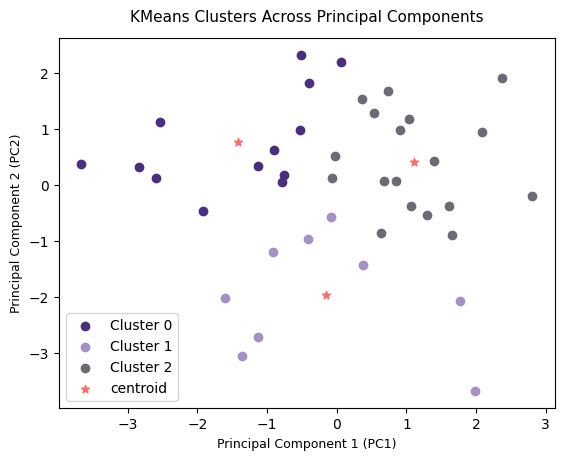

In [ ]:
dataset['PC1'] = X_pca[:, 0]
dataset['PC2'] = X_pca[:, 1]

km = KMeans(n_clusters=3, n_init='auto', random_state=0)

dataset['cluster'] = km.fit_predict(dataset[['PC1', 'PC2']])

df0 = dataset[dataset.cluster == 0]
df1 = dataset[dataset.cluster == 1]
df2 = dataset[dataset.cluster == 2]

plt.scatter(df0.PC1, df0.PC2, color='#4A2E80', label='Cluster 0')
plt.scatter(df1.PC1, df1.PC2, color='#A390C6', label='Cluster 1')
plt.scatter(df2.PC1, df2.PC2, color='#6E6A75', label='Cluster 2')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='#FF6B6B', marker = '*', label='centroid')

plt.title('KMeans Clusters Across Principal Components', fontsize=11, pad=12)
plt.xlabel('Principal Component 1 (PC1)', fontsize=9)
plt.ylabel('Principal Component 2 (PC2)', fontsize=9)
plt.legend()
plt.show()

Checking which Brands are in each cluster

Cluster 0:

In [ ]:
print(dataset[dataset.cluster == 0]['Brand'].values)

['Bourjois' 'Danessa Myricks' 'Farsali' 'IT Cosmetics' 'Kylie Cosmetics'
 'Laura Mercier' 'Make Up For Ever' 'Natasha Denona' 'Pat McGrath Labs'
 'Patrick Ta' 'RMS Beauty' 'Tarte' 'Urban Decay']


In [ ]:
brands_in_cluster_0 = dataset[dataset['cluster'] == 0][['Brand']]

cluster_0_brands = brands_in_cluster_0.style\
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px 12px',
        'border-bottom': '1px solid #E6E1F0', 
        'font-family': 'sans-serif',
        'font-size': '12px',
        'color': '#2D2738' 
    })\
   .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#4A2E80'), 
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '12px'),
            ('border', 'none')
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#F8F6FC') 
        ]},
        {'selector': 'tbody', 'props': [
            ('border-bottom', '2px solid #4A2E80')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('color', '#4A2E80'),
            ('padding-bottom', '8px'),
            ('text-align', 'left')
        ]}
    ])\
    .set_caption("Table: Cluster Analysis Results Preview")\
    .hide(axis='index')

cluster_0_brands
   

with open("cluster_0_brands.html", "w") as f:
    f.write(cluster_0_brands.to_html())

Cluster 1: 

In [ ]:
print(dataset[dataset.cluster == 1]['Brand'].values)

['Bite Beauty' 'Bobby Brown' 'E.l.f.' 'Kiehl’s' 'Morphe' 'NARS'
 'Rare Beauty' 'Sisley' 'Tatcha']


Cluster 2:

In [ ]:
print(dataset[dataset.cluster == 2]['Brand'].values)

['Anastasia Beverly Hills' 'Becca' 'Charlotte Tilbury' 'Clinique'
 'ColourPop' 'Drunk Elephant' 'Fenty Beauty' 'Glossier' 'Hourglass'
 'Huda Beauty' 'Ilia Beauty' 'Juvia’s Place' 'KVD Beauty' 'Milk Makeup'
 'Perricone MD' 'Shiseido' 'Too Faced' 'Yves Saint Laurent']


In [ ]:
cluster_averages = dataset.groupby('cluster').mean(numeric_only=True).T
display(cluster_averages)

cluster,0,1,2
Price_USD,0.597881,0.196883,0.604223
Rating,2.983135,3.009251,3.011806
Number_of_Reviews,4874.565327,5076.778650,5081.894327
Is_Certified_Cruelty_Free,0.000000,0.222222,0.166667
Toxic_Chemical_Amount,364.538462,390.555556,374.777778
Is_Skincare,0.295042,0.314163,0.296817
Skin_Type,1.978785,1.999723,2.012627
Product_Size,128.962609,128.240704,130.081589
Usage_Frequency,1.743898,1.782332,1.714750
Gender_Target,0.330525,0.355293,0.321523


In [ ]:
print(dataset.columns.tolist())

['Brand', 'Price_USD', 'Rating', 'Number_of_Reviews', 'Is_Certified_Cruelty_Free', 'Toxic_Chemical_Amount', 'Is_Skincare', 'Skin_Type', 'Product_Size', 'Usage_Frequency', 'Gender_Target', 'Packaging_Type', 'Has_Active_Ingredients', 'European_Origin', 'cluster', 'PC1', 'PC2']


In [ ]:
cluster_averages.columns = ['Cluster 0', 'Cluster 1', 'Cluster 2']
cluster_variables = ['Price_USD', 'Rating', 'Number_of_Reviews', 'Is_Certified_Cruelty_Free', 'Toxic_Chemical_Amount', 'Is_Skincare', 'Skin_Type', 'Product_Size', 'Usage_Frequency', 'Gender_Target']

cluster_averages = cluster_averages.loc[cluster_variables]

cluster_averages_table = cluster_averages.style\
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px 12px',
        'border-bottom': '1px solid #E6E1F0', 
        'font-family': 'sans-serif',
        'font-size': '12px',
        'color': '#2D2738' 
    })\
   .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#4A2E80'), 
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '12px'),
            ('border', 'none')
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#F8F6FC') 
        ]},
        {'selector': 'tbody', 'props': [
            ('border-bottom', '2px solid #4A2E80')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('color', '#4A2E80'),
            ('padding-bottom', '8px'),
            ('text-align', 'left')
        ]}
    ])\
    .set_caption("Table: Cluster Average Per Variable")\
    
cluster_averages_table
   

with open("cluster_averages_table.html", "w") as f:
    f.write(cluster_averages_table.to_html())

# Step 5 Normalisation

Checking for outliers in PC'S and The 3 key variables

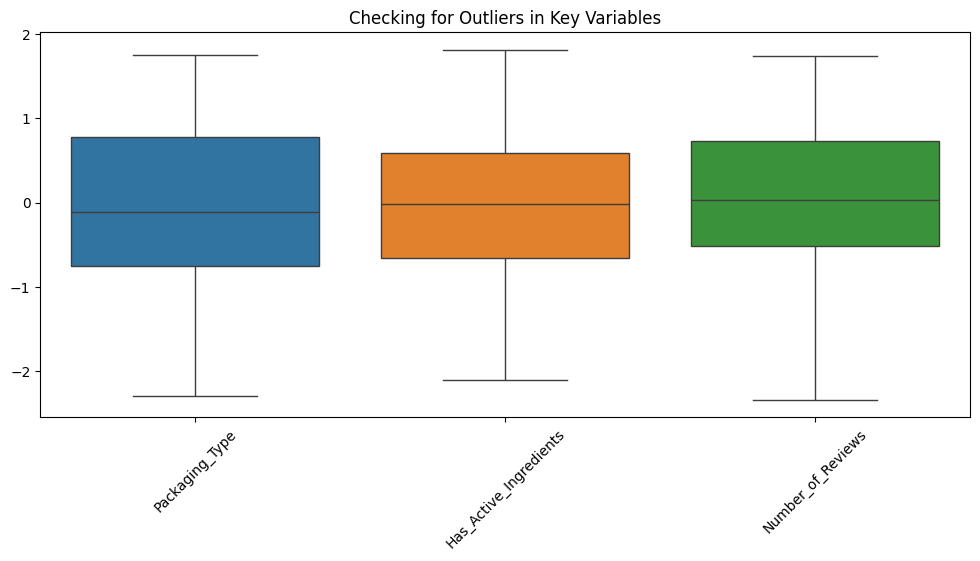

In [ ]:
temp_scaled_data = pd.DataFrame(X_scaled, columns=X.columns)

plt.figure(figsize=(10, 5))
sns.boxplot(data =  temp_scaled_data[['PC1', 'PC2']])
plt.title("Checking for Outliers using Principal Components")
plt.ylabel("Standardised Values")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data = temp_scaled_data[['Packaging_Type', 'Has_Active_Ingredients', 'Number_of_Reviews']])
plt.title("Checking for Outliers in Key Variables")
plt.xticks(rotation=45)
plt.show()

In [ ]:
X_scaled

array([[ 7.38050226e-01,  8.80826437e-01,  6.16900791e-02,
         2.64575131e+00, -2.83015719e-01, -5.61483713e-01,
         4.65149831e-01, -3.22690572e-01,  4.80697051e-01,
         9.71680365e-01,  1.08800059e+00, -2.65245879e-02,
        -6.59994144e-01],
       [ 1.17759466e+00,  1.69631405e+00,  7.37002371e-01,
        -3.77964473e-01,  6.13200725e-01,  1.29705095e+00,
        -4.44747381e-01, -1.95113725e-01, -4.44557607e-01,
        -7.64076641e-01, -4.98248085e-01, -1.25304154e-02,
        -1.72256294e-01],
       [-1.33610173e+00,  1.10514292e+00,  1.32152846e+00,
         2.64575131e+00,  8.01877872e-01,  1.37271688e+00,
         1.18420945e+00, -1.94247030e+00,  9.96093288e-01,
         8.53167425e-01,  1.23197162e+00,  1.62408164e-01,
        -6.69465350e-01],
       [-1.14517597e+00, -6.11064483e-01,  1.34695661e-01,
        -3.77964473e-01,  2.35846433e-01,  1.08480406e-01,
         1.56957074e+00,  1.82163866e+00,  5.10971660e-01,
         8.78571907e-01, -5.29635801e

# Step 6 Weighting and Aggregation

In [ ]:
print(pca.explained_variance_ratio_)

[0.17054768 0.14727831 0.11021545 0.10584056 0.08768528 0.07733068
 0.06966904 0.06801946 0.04818961 0.04036247 0.03495469]


# Step 6 Weighting and Aggregation

In [ ]:
# Using the values above for pc1 and pc2
weight_pc1 = 0.17054768
weight_pc2 = 0.14727831
total_variance = weight_pc1 + weight_pc2

dataset['Composite_Index'] = (dataset['PC1'] * weight_pc1 + dataset['PC2'] * weight_pc2) / total_variance

,Brand,cluster,Final_Brand_Score
33,Shiseido,2,100.000000
7,ColourPop,2,86.039564
19,KVD Beauty,2,82.746859
39,Yves Saint Laurent,2,77.012903
17,Ilia Beauty,2,75.468882
16,IT Cosmetics,0,74.148764
6,Clinique,2,71.824688
37,Too Faced,2,71.585714
18,Juvia’s Place,2,71.011769
5,Charlotte Tilbury,2,70.449958


Using one final score based only on PC1 and PC2

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 100))
dataset['Final_Brand_Score'] = scaler.fit_transform(dataset[['Composite_Index']])

dataset.sort_values(by='Final_Brand_Score', ascending=False)[['Brand', 'cluster', 'Final_Brand_Score']]

Index Score using Sub Indicators

In [ ]:
# Normalise using MinMaxScaler between 0 and 100
scaler = MinMaxScaler(feature_range=(0, 100))

# Scaled Variables 
dataset['scaled_price'] = scaler.fit_transform(dataset[['Price_USD']])
dataset['scaled_rating'] = scaler.fit_transform(dataset[['Rating']])
dataset['scaled_reviews'] = scaler.fit_transform(dataset[['Number_of_Reviews']])
dataset['scaled_packaging'] = scaler.fit_transform(dataset[['Packaging_Type']])
dataset['scaled_active'] = scaler.fit_transform(dataset[['Has_Active_Ingredients']])

# The sub indexes 
dataset['Market_Affordability_Index'] = dataset['scaled_price']
dataset['Consumer_Acceptance_Index'] = (dataset['scaled_rating'] + dataset['scaled_reviews']) / 2
dataset['Packaging_Sustainability_Index'] = (dataset['scaled_packaging'])  
dataset['Ethical_Compliance_Index'] = dataset['scaled_active']            
dataset['Product_Safety_Index'] = 100 - dataset['scaled_active']      

sub_index_columns = [
    'Market_Affordability_Index', 'Consumer_Acceptance_Index', 
    'Packaging_Sustainability_Index', 'Ethical_Compliance_Index', 'Product_Safety_Index'
]

# Using the mean of all the sub indicators
dataset['Final_Brand_Score'] = dataset[sub_index_columns].mean(axis=1)

dataset.sort_values(by='Final_Brand_Score', ascending=True)[
    ['Brand'] + sub_index_columns + ['Final_Brand_Score']
]

,Brand,Market_Affordability_Index,Consumer_Acceptance_Index,Versatility_Index,Ethical_Compliance_Index,Product_Safety_Index,Final_Brand_Score
26,NARS,0.000000,64.646456,0.000000,30.674518,69.325482,32.929291
28,Pat McGrath Labs,5.620958,26.181814,34.895610,91.094024,8.905976,33.339676
29,Patrick Ta,41.886302,4.421148,36.626644,72.907551,27.092449,36.586819
31,RMS Beauty,26.469596,40.044406,28.041312,100.000000,0.000000,38.911063
20,Kiehl’s,15.280195,30.280855,51.768175,62.891470,37.108530,39.465845
27,Natasha Denona,70.089693,19.885765,8.826604,57.773136,42.226864,39.760412
9,Drunk Elephant,8.602193,39.041625,55.948039,43.455567,56.544433,40.718372
25,Morphe,23.869164,58.034601,23.974302,68.235153,31.764847,41.175613
3,Bobby Brown,19.836566,43.204474,43.523984,57.581990,42.418010,41.313005
32,Rare Beauty,1.439734,47.527306,72.648445,0.000000,100.000000,44.323097
